In [1]:
import uproot
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from scipy.stats import binned_statistic

filename = "tree_outfile_complete_tree_overlays.root"

file = uproot.open(filename)
tree = file["outree"]

print(file.keys())
print(tree)
print(tree.num_entries)
print(tree.keys())

plane = tree["plane"].array(library="np")
hit_wires = tree["hit_wires"].array(library="np")
tot_wires = tree["tot_wires"].array(library="np")
avg_pitch = tree["avg_pitch"].array(library="np")
g4id = tree["G4ID"].array(library="np")
truth_fraction = tree["truth_fraction"].array(library="np")
max_buco = tree["max_buco"].array(library="np")

['outree;1']
<TTree 'outree' (22 branches) at 0x0001772574d0>
1933492
['run', 'evt', 'cryo', 'tpc', 'plane', 'min_wire', 'max_wire', 'start', 'end', 'hit_wires', 'tot_wires', 'avg_pitch', 'trk_length', 'max_buco', 'whicht0', 't0PFP', 't0CRTTrack', 't0CRTHit', 'nholes', 'wire_holes', 'G4ID', 'truth_fraction']


In [2]:
def TProfile(mask) :
    average_pitch = avg_pitch[mask]
    eff = hit_wires[mask]/tot_wires[mask]

    mean_y, x_edges, binnumber = binned_statistic(average_pitch, eff, statistic='mean', bins=400, range=(0,4))
    std_y, _, _ = binned_statistic(average_pitch, eff, statistic='std', bins=400, range=(0,4))

    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])

    counts, _ = np.histogram(average_pitch, bins=400, range=(0,4))
    err_y = std_y / np.sqrt(counts)

    return x_centers, mean_y, err_y

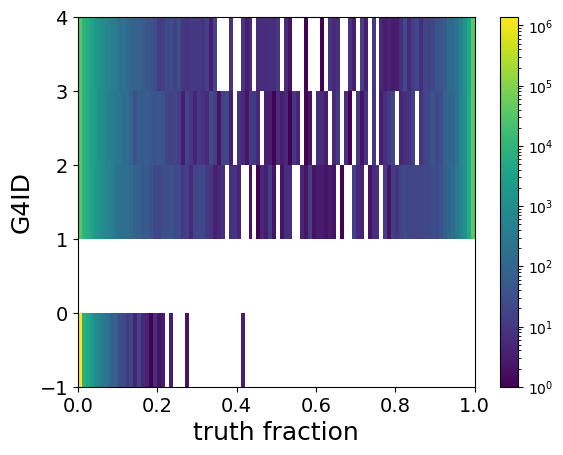

In [3]:
h = plt.hist2d(truth_fraction[max_buco < 10],g4id[max_buco < 10],bins=(100,5),range=[(0,1),(-1,4)],cmap='viridis', norm=LogNorm())
plt.xlabel('truth fraction', fontsize=18)
plt.ylabel('G4ID', fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
cbar = plt.colorbar(h[3])

In [16]:
PLANE = 1

(0.8, 1.0)

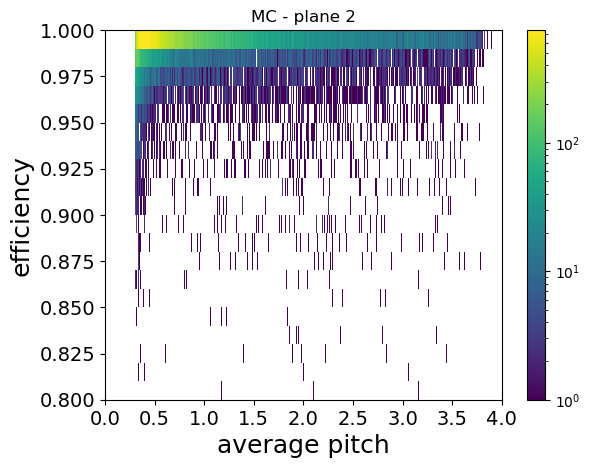

In [9]:
mask = ((plane==PLANE) & (g4id != -1) & (truth_fraction >= 0.8) & (max_buco < 10))
#mask = ((plane==PLANE) & (g4id != -1) & (truth_fraction < 0.2) & (max_buco < 10))
#mask = ((plane==PLANE) & (g4id == -1) & (truth_fraction == 0) & (max_buco < 10))
#mask = ((plane==PLANE) & (g4id == -1) & (max_buco < 10))
h2_coll = plt.hist2d(avg_pitch[mask],hit_wires[mask]/tot_wires[mask],bins=(400,100),range=[(0,4),(0,1.0)],cmap='viridis', norm=LogNorm())
plt.xlabel('average pitch', fontsize=18)
plt.ylabel('efficiency', fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title("MC - plane {}".format(PLANE))
cbar = plt.colorbar(h2_coll[3])
plt.ylim(0.8,1)


(0.8, 1.0)

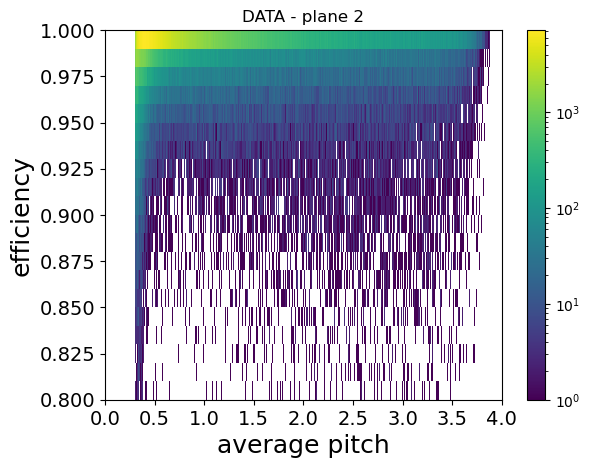

In [8]:
#mask = ((plane==PLANE) & (g4id != -1) & (truth_fraction >= 0.8) & (max_buco < 10))
#mask = ((plane==PLANE) & (g4id != -1) & (truth_fraction < 0.2) & (max_buco < 10))
#mask = ((plane==PLANE) & (g4id == -1) & (truth_fraction == 0) & (max_buco < 10))
mask = ((plane==PLANE) & (g4id == -1) & (max_buco < 10))
h2_coll = plt.hist2d(avg_pitch[mask],hit_wires[mask]/tot_wires[mask],bins=(400,100),range=[(0,4),(0,1.0)],cmap='viridis', norm=LogNorm())
plt.xlabel('average pitch', fontsize=18)
plt.ylabel('efficiency', fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title("DATA - plane {}".format(PLANE))
cbar = plt.colorbar(h2_coll[3])
plt.ylim(0.8,1)

(0.99, 1.0)

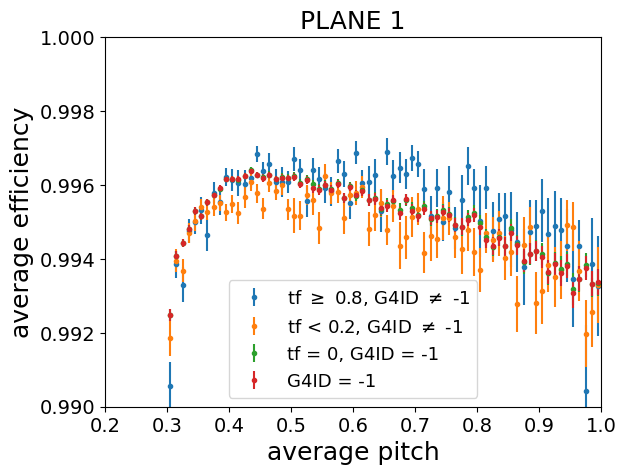

In [19]:
x_centers_MC, mean_y_MC, err_y_MC = TProfile(((plane==PLANE) & (g4id != -1) & (truth_fraction >= 0.8) & (max_buco < 10)))
x_centers_MC_low, mean_y_MC_low, err_y_MC_low = TProfile(((plane==PLANE) & (g4id != -1) & (truth_fraction < 0.2) & (max_buco < 10)))
x_centers_DATA, mean_y_DATA, err_y_DATA = TProfile(((plane==PLANE) & (g4id == -1) & (truth_fraction == 0) & (max_buco < 10)))
x_centers_DATA_all, mean_y_DATA_all, err_y_DATA_all = TProfile(((plane==PLANE) & (g4id == -1) & (max_buco < 10)))

plt.errorbar(x_centers_MC, mean_y_MC, yerr=err_y_MC, fmt='.', label = r'tf $\geq$ 0.8, G4ID $\neq$ -1')
plt.errorbar(x_centers_MC_low, mean_y_MC_low, yerr=err_y_MC_low, fmt='.', label = r'tf < 0.2, G4ID $\neq$ -1')
plt.errorbar(x_centers_DATA, mean_y_DATA, yerr=err_y_DATA, fmt='.', label = r'tf = 0, G4ID = -1')
plt.errorbar(x_centers_DATA_all, mean_y_DATA_all, yerr=err_y_DATA_all, fmt='.', label = r'G4ID = -1')
plt.xlabel('average pitch', fontsize=18)
plt.ylabel('average efficiency', fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title("PLANE {}".format(PLANE), fontsize = 18)
plt.legend(loc = 'best', fontsize = 13)
plt.xlim(0.2,1)
plt.ylim(0.99,1.)